# Avaliação do Modelo — Conjunto de Teste

Este notebook avalia os modelos finais treinados no conjunto de dados de teste,
utilizando métricas de classificação e matrizes de confusão.

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from preprocessing import preprocess_data
from train import train_models


In [7]:
results, models, (X_test, y_test) = train_models()

c:\Users\lucc-\OneDrive\Documents\facul\gitHub\dIAbetes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Model: Logistic Regression (GridSearch)
Accuracy: 0.7130
Precision: 0.5946
Recall: 0.5500
F1_score: 0.5714

Model: Decision Tree (RandomSearch)
Accuracy: 0.6957
Precision: 0.5610
Recall: 0.5750
F1_score: 0.5679

Model: SGD Classifier
Accuracy: 0.6696
Precision: 0.5208
Recall: 0.6250
F1_score: 0.5682


In [8]:
best_model_name = max(
    results,
    key=lambda m: results[m]["recall"]
)

best_model = models[best_model_name]

print(f"Best model based on recall: {best_model_name}")


Best model based on recall: SGD Classifier


In [5]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        75
           1       0.68      0.61      0.64        41

    accuracy                           0.76       116
   macro avg       0.74      0.72      0.73       116
weighted avg       0.75      0.76      0.76       116



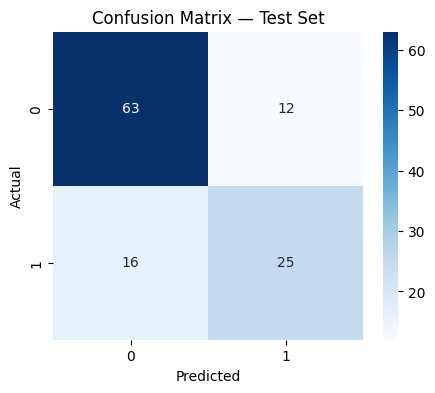

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

## Avaliação no Conjunto de Teste

O modelo selecionado demonstrou um bom desempenho de generalização no
conjunto de dados de teste. A matriz de confusão indica que o modelo
minimiza os falsos negativos, o que é um aspecto crítico em cenários de
diagnóstico médico, como a detecção de diabetes.
